In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
import tensorflow_probability as tfp
import joblib
import gpflow

/Users/smoon1/anaconda3/envs/ts/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
root_fp = "/Users/smoon1/Downloads/"
data_fp = root_fp + "data-1015/"
key_fp = "sensor_events_1120.csv"
save_dir = "saved_model_0"

events = pd.read_csv(key_fp).dropna(subset=["label","deployment_id","start_time","end_time"])
sensors = events.deployment_id.unique()

s = sensors[0]
thresh = 0.33

In [3]:
s

'daily_happy_satyr'

In [4]:
def read_sensor_csvs(s, data_fp):
    #read in all the data from one sensor
    
    data_fps = glob.glob(data_fp + s + "/*")
    if len(data_fps) > 0:
        data = pd.concat([pd.read_csv(dfp) for dfp in data_fps])
        data = data.sort_values(by = "time").reset_index(drop = True)
        data = data.dropna(subset = ["time","depth_filt_mm"])
        data["time"] = pd.to_datetime(data["time"],format="ISO8601").dt.strftime('%Y-%m-%d %H:%M:%S.%f')
        data["time"] = pd.to_datetime(data['time']).dt.floor('ms')
        #"%Y-%m-%d %H:%M:%S.%f+%z")
    
        return data 


def evaluate_result(data):
    #extract timestamps and measured data as vectors from the measured signal df
    if data["depth_filt_mm"].values is not None:
        measured = data["depth_filt_mm"].values

        min_time = data["time"].min()
        max_time = data["time"].max()
    
        time = (data["time"] - min_time).dt.total_seconds() / (max_time - min_time).total_seconds()
        min_time = data["time"].min()
        max_time = data["time"].max()
        
        time = time.values.reshape(-1,1)
        # depth_mean = np.mean(measured)
        # depth_sd = np.std(measured)
        # depth_norm = (measured-depth_mean)/depth_sd
        my_scaler = joblib.load('scaler.gz')
        depth_norm = my_scaler.transform(measured.reshape(-1,1))
        y_mean, y_var = flood_gp.compiled_predict_y(time)
        y_lower = y_mean - 1.98 * np.sqrt(y_var)
        y_upper = y_mean + 1.98 * np.sqrt(y_var)

        non_flood_events = np.logical_or(depth_norm < y_lower, depth_norm > y_upper)
        num_non_flood_detected = np.sum(non_flood_events)
        non_flood_detected = num_non_flood_detected / len(non_flood_events)

        return non_flood_detected
        

def plot_predictions(data):
    
    #extract timestamps and measured data as vectors from the measured signal df
    min_time = data["time"].min()
    max_time = data["time"].max()

    time = (data["time"] - min_time).dt.total_seconds() / (max_time - min_time).total_seconds()
    time = time.values.reshape(-1,1)
    measured = data["depth_filt_mm"].values.reshape(-1,1)
    # depth_mean = np.mean(measured)
    # depth_sd = np.std(measured)
    # depth_norm = (measured-depth_mean)/depth_sd
    
    my_scaler = joblib.load('scaler.gz')
    depth_norm = my_scaler.transform(measured)

    y_mean, y_var = flood_gp.compiled_predict_y(time)
    y_lower = y_mean - 1.98 * np.sqrt(y_var)
    y_upper = y_mean + 1.98 * np.sqrt(y_var)
    
    plt.figure(figsize=(14, 8))
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6))
    ax.plot(time, depth_norm, "kx", mew=2, alpha=0.8, zorder=1)
    (mean_line,) = ax.plot(time, y_mean, "-", zorder=5, label='mean_line')
    color = mean_line.get_color()
    ax.plot(time, y_lower, lw=0.1, color=color,zorder=4)
    ax.plot(time, y_upper, lw=0.1, color=color,zorder=3)
    ax.fill_between(
        time[:, 0], y_lower[:, 0], y_upper[:, 0], color=color, alpha=0.3, label='95% CI', zorder=2
    )
  
    plt.xlabel('Normalized Time')
    plt.ylabel('Standardized Depth')
    # plt.title(f'''Data of One {data['label'].unique()}''')
    plt.legend()


In [5]:
events

,annotated_by,annotation_session,date_created,date_updated,deployment_id,end_time,event_confidence,id,label,start_time,dev_id,last_depth_proc_mm,max_depth_proc_mm,mean_depth_proc_mm,msg_count,sum_precip_5min_mm,tidally_influenced
0,human,NaN,NaN,2024-10-28 19:08:31.188262+00:00,daily_happy_satyr,2024-06-07 03:12:35.157000,0.944007,494408,flood,2024-06-06 23:27:23.084000,fs-00022,0.0,310.0,187.0,52.0,0.0,True
1,human,NaN,NaN,2024-10-28 19:08:39.474907+00:00,daily_happy_satyr,2024-06-08 03:12:44.426000,0.752507,494474,flood,2024-06-08 00:07:52.838000,fs-00022,0.0,147.0,97.0,15.0,0.0,True
2,NaN,NaN,NaN,2024-10-28 18:24:07.104000+00:00,fluttering_massive_faucet,2024-10-28 18:27:16.286000,0.000000,392828,blip,2024-10-28 18:24:07.104000,fs-00091,0.0,0.0,0.0,0.0,NaN,NaN
3,NaN,NaN,NaN,2024-10-28 18:43:50.554000+00:00,poorly_set_cougar,2024-10-28 18:45:55.017000,0.000000,537215,blip,2024-10-28 18:42:49.808000,fs3-00132,0.0,0.0,0.0,1.0,NaN,NaN
4,NaN,NaN,NaN,2024-10-28 18:35:34.223000+00:00,daily_expert_whale,2024-10-28 18:36:35.360000,0.000000,392894,blip,2024-10-28 18:35:34.223000,fs3-00013,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163119,NaN,NaN,NaN,2024-11-20 04:47:00.045000+00:00,mildly_tough_spider,2024-11-20 04:49:06.338,0.000000,860981,blip,2024-11-20 04:45:56.899,fs3-00067,20.0,26.0,23.0,1.0,NaN,NaN
163120,NaN,NaN,NaN,2024-11-20 04:47:21.768000+00:00,curly_furry_squirrel,2024-11-20 04:49:28.467,0.000000,860986,blip,2024-11-20 04:48:25.117,fs3-00237,0.0,0.0,0.0,0.0,NaN,NaN
163122,NaN,NaN,NaN,2024-11-20 05:01:47.033000+00:00,mildly_tough_spider,2024-11-20 05:02:50.164,0.000000,861158,blip,2024-11-20 05:00:43.888,fs3-00067,0.0,0.0,0.0,0.0,NaN,NaN
163123,human,NaN,NaN,2024-11-20 05:03:28.063708+00:00,daily_happy_satyr,2023-08-30 13:29:46.075,0.852016,432952,flood,2023-08-30 11:07:36.940,fs-00022,0.0,110.0,70.0,24.0,0.0,True


In [6]:
events["start_time"] = pd.to_datetime(events["start_time"],format="ISO8601")#"%Y-%m-%d %H:%M:%S.%f+%z")
events["end_time"] = pd.to_datetime(events["end_time"],format="ISO8601")#"%Y-%m-%d %H:%M:%S.%f+%z")
print(len(events))
print(len(events[events['deployment_id']=='daily_happy_satyr']))
daily_happy_satyr = events[events['deployment_id']=='daily_happy_satyr'].copy()
daily_happy_satyr = daily_happy_satyr[daily_happy_satyr['label']!='flood']
daily_happy_satyr = daily_happy_satyr.loc[daily_happy_satyr['end_time'] < '2024-10-16'].reset_index(drop=True)
daily_happy_satyr

161324
1637


,annotated_by,annotation_session,date_created,date_updated,deployment_id,end_time,event_confidence,id,label,start_time,dev_id,last_depth_proc_mm,max_depth_proc_mm,mean_depth_proc_mm,msg_count,sum_precip_5min_mm,tidally_influenced
0,human,NaN,NaN,2024-10-28 19:08:22.657392+00:00,daily_happy_satyr,2024-06-05 01:07:02.621000,0.000029,494138,ugly-flood,2024-06-04 01:47:07.451000,fs-00022,0.0,183.0,126.0,17.0,0.0,True
1,human,NaN,NaN,2024-10-28 19:07:49.088950+00:00,daily_happy_satyr,2024-05-23 03:18:49.060000,0.467553,492541,ugly-flood,2024-05-22 23:38:05.580000,fs-00022,0.0,50.0,33.0,61.0,0.0,True
2,human,NaN,NaN,2024-10-28 19:07:59.906075+00:00,daily_happy_satyr,2024-05-24 13:28:58.624000,0.956337,492791,ugly-flood,2024-05-24 00:26:59.355000,fs-00022,0.0,56.0,18.0,225.0,0.0,True
3,amrutha,NaN,NaN,2024-04-01 00:00:00+00:00,daily_happy_satyr,2021-12-10 19:00:12.452648,0.000000,394275,blip,2021-12-10 18:47:37.299706,fs-00022,0.0,250.0,100.0,12.0,0.0,True
4,auto,NaN,NaN,2024-10-01 00:00:00+00:00,daily_happy_satyr,2021-12-12 05:28:00.446092,0.000000,394277,noise,2021-12-11 14:56:48.359715,fs-00022,0.0,0.0,0.0,8.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,human,NaN,NaN,2024-10-29 12:07:26.766607+00:00,daily_happy_satyr,2023-09-16 03:48:30.762000,0.552174,437053,noise,2023-09-16 01:47:35.599000,fs-00022,0.0,18.0,14.0,41.0,0.0,True
1304,human,NaN,NaN,2024-10-29 19:19:52.707400+00:00,daily_happy_satyr,2023-05-19 01:12:38.684000,0.603060,415995,ugly-flood,2023-05-19 00:20:06.231000,fs-00022,0.0,25.0,20.0,20.0,0.0,True
1305,human,NaN,NaN,2024-10-29 19:15:16.899904+00:00,daily_happy_satyr,2022-12-21 11:10:37.251000,0.000000,405091,noise,2022-12-21 11:04:19.476000,fs-00022,0.0,0.0,0.0,2.0,0.0,True
1306,human,NaN,NaN,2024-11-05 17:37:14.882544+00:00,daily_happy_satyr,2022-03-26 02:20:57.697511,0.167553,395095,noise,2022-03-26 01:13:40.500249,fs-00022,0.0,30.0,25.0,24.0,0.0,True


In [7]:
sensor_data = read_sensor_csvs('daily_happy_satyr', data_fp)[['time', 'depth_filt_mm']]
sensor_data

,time,depth_filt_mm
0,2021-12-10 18:45:31.583,0.0
1,2021-12-10 18:46:34.336,0.0
2,2021-12-10 18:47:37.299,0.0
3,2021-12-10 18:48:39.853,70.0
4,2021-12-10 18:49:43.135,250.0
...,...,...
444450,2024-10-15 02:25:50.180,0.0
444451,2024-10-15 02:26:53.664,0.0
444452,2024-10-15 02:30:02.750,0.0
444453,2024-10-15 02:42:39.686,0.0


In [8]:
event_dataframes = {}

for ix, event_row in daily_happy_satyr.iterrows():
    start_time = event_row['start_time']
    end_time = event_row['end_time']
    event = event_row['label']

    event_df = sensor_data[(sensor_data['time'] >= start_time) & (sensor_data['time'] <= end_time)].copy()
    # event_df = event_df[event_df['depth_filt_mm']!=0]
    event_df['label'] = event
    event_dataframes[ix] = event_df  # Store the filtered DataFrame in the dictionary

In [9]:
flood_gp = tf.saved_model.load(save_dir)

In [10]:
event_dataframes[0]

,time,depth_filt_mm,label
411573,2024-06-04 01:47:07.451,0.0,ugly-flood
411574,2024-06-04 23:52:33.506,193.0,ugly-flood
411575,2024-06-04 23:54:40.788,192.0,ugly-flood
411576,2024-06-05 00:03:03.700,183.0,ugly-flood
411577,2024-06-05 00:09:21.154,175.0,ugly-flood
411578,2024-06-05 00:13:33.211,166.0,ugly-flood
411579,2024-06-05 00:16:41.806,159.0,ugly-flood
411580,2024-06-05 00:26:08.857,136.0,ugly-flood
411581,2024-06-05 00:28:15.211,130.0,ugly-flood
411582,2024-06-05 00:54:28.631,39.0,ugly-flood


In [11]:
#sample level
results = []
for key, value in event_dataframes.items():
    if len(value) != 0:
        result = evaluate_result(value)
        results.append(result)

results = np.array(results)
mean = np.mean(results)
print(f'filtering result: {mean}')


2024-12-12 16:05:55.405562: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


filtering result: 0.2923074002801357


In [12]:
#event level
results[results > 0.75].shape[0] / results.shape[0]*100

0.22988505747126436

<Figure size 1400x800 with 0 Axes>

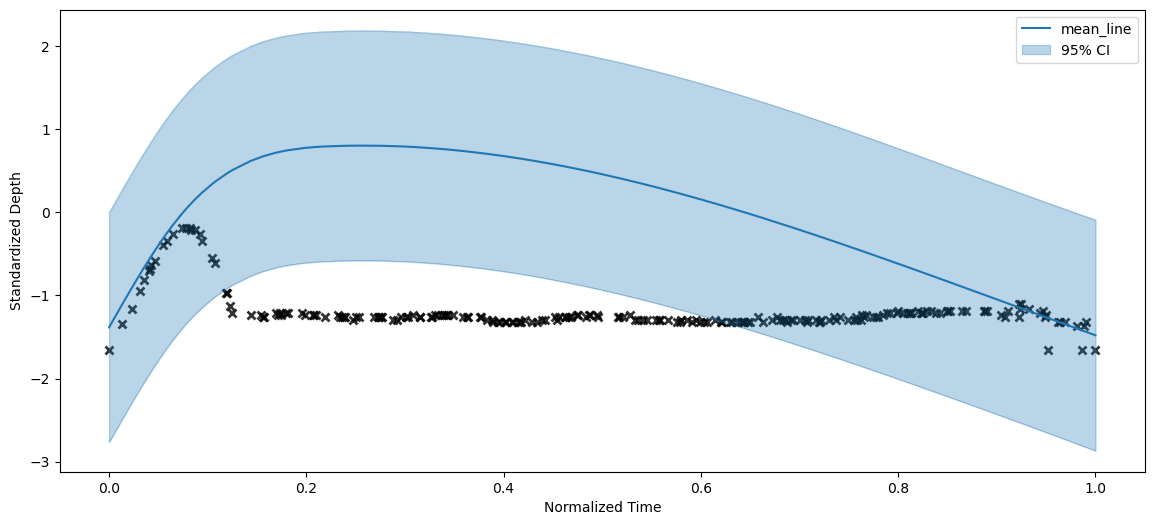

In [13]:
plot_predictions(event_dataframes[2])

In [14]:
results[results > mean]

array([0.66666667, 0.32142857, 0.5       , 0.33333333, 0.33333333,
       0.42857143, 0.53333333, 0.375     , 0.44444444, 0.375     ,
       0.44117647, 0.55555556, 0.46153846, 0.41666667, 0.375     ,
       0.41666667, 0.33333333, 0.3902439 , 0.38461538, 0.44      ,
       0.53333333, 0.33333333, 0.42553191, 0.42105263, 0.35714286,
       0.35714286, 0.38888889, 0.35294118, 0.68190855, 0.44117647,
       0.38461538, 0.4       , 0.4       , 0.5       , 0.44      ,
       0.375     , 0.5       , 0.4       , 0.31578947, 0.45882353,
       0.33333333, 0.91666667, 0.625     , 0.47297297, 0.45555556,
       0.33333333, 0.42352941, 0.4       , 0.46153846, 0.33333333,
       0.46875   , 0.45      , 0.47058824, 0.375     , 0.52380952,
       0.46875   , 0.31818182, 0.41104294, 0.42553191, 0.47619048,
       0.5       , 0.44444444, 0.31465517, 0.49635036, 0.33333333,
       0.45098039, 0.38636364, 0.47663551, 0.44      , 0.47826087,
       0.47058824, 0.46153846, 0.55555556, 0.47058824, 0.4    

In [15]:
events["start_time"] = pd.to_datetime(events["start_time"],format="ISO8601")#"%Y-%m-%d %H:%M:%S.%f+%z")
events["end_time"] = pd.to_datetime(events["end_time"],format="ISO8601")#"%Y-%m-%d %H:%M:%S.%f+%z")
print(len(events))
print(len(events[events['deployment_id']=='daily_happy_satyr']))
daily_happy_satyr = events[events['deployment_id']=='daily_happy_satyr'].copy()
daily_happy_satyr = daily_happy_satyr.loc[daily_happy_satyr['end_time'] < '2024-10-16'].reset_index(drop=True)
daily_happy_satyr

161324
1637


,annotated_by,annotation_session,date_created,date_updated,deployment_id,end_time,event_confidence,id,label,start_time,dev_id,last_depth_proc_mm,max_depth_proc_mm,mean_depth_proc_mm,msg_count,sum_precip_5min_mm,tidally_influenced
0,human,NaN,NaN,2024-10-28 19:08:31.188262+00:00,daily_happy_satyr,2024-06-07 03:12:35.157000,0.944007,494408,flood,2024-06-06 23:27:23.084000,fs-00022,0.0,310.0,187.0,52.0,0.0,True
1,human,NaN,NaN,2024-10-28 19:08:39.474907+00:00,daily_happy_satyr,2024-06-08 03:12:44.426000,0.752507,494474,flood,2024-06-08 00:07:52.838000,fs-00022,0.0,147.0,97.0,15.0,0.0,True
2,human,NaN,NaN,2024-10-28 19:08:06.974785+00:00,daily_happy_satyr,2024-06-04 00:11:31.642000,0.927931,494122,flood,2024-06-03 21:43:22.020000,fs-00022,0.0,158.0,105.0,42.0,0.0,True
3,human,NaN,NaN,2024-10-28 19:08:22.657392+00:00,daily_happy_satyr,2024-06-05 01:07:02.621000,0.000029,494138,ugly-flood,2024-06-04 01:47:07.451000,fs-00022,0.0,183.0,126.0,17.0,0.0,True
4,human,NaN,NaN,2024-10-28 19:08:27.697299+00:00,daily_happy_satyr,2024-06-06 01:53:16.502000,0.924157,494218,flood,2024-06-05 22:58:46.537000,fs-00022,0.0,184.0,127.0,40.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1568,human,NaN,NaN,2024-10-29 19:15:41.823533+00:00,daily_happy_satyr,2023-02-19 12:48:45.124000,0.740855,408593,flood,2023-02-19 12:04:40.059000,fs-00022,0.0,19.0,15.0,17.0,0.0,True
1569,human,NaN,NaN,2024-11-05 17:37:14.882544+00:00,daily_happy_satyr,2022-03-26 02:20:57.697511,0.167553,395095,noise,2022-03-26 01:13:40.500249,fs-00022,0.0,30.0,25.0,24.0,0.0,True
1570,human,NaN,NaN,2024-11-05 19:31:12.381634+00:00,daily_happy_satyr,2024-03-07 11:06:35.358000,0.008847,479573,ugly-flood,2024-03-07 09:49:58.916000,fs-00022,0.0,19.0,16.0,40.0,0.0,True
1571,human,NaN,NaN,2024-11-20 05:04:02.148948+00:00,daily_happy_satyr,2024-06-09 03:59:03.079000,0.837696,494513,flood,2024-06-09 01:31:53.122000,fs-00022,0.0,74.0,46.0,23.0,0.0,True


In [16]:
event_dataframes = {}

for ix, event_row in daily_happy_satyr.iterrows():
    start_time = event_row['start_time']
    end_time = event_row['end_time']
    event = event_row['label']

    event_df = sensor_data[(sensor_data['time'] >= start_time) & (sensor_data['time'] <= end_time)].copy()
    event_df['label'] = event
    event_dataframes[ix] = event_df  # Store the filtered DataFrame in the dictionary

In [17]:
#sample level
results = []
for key, value in event_dataframes.items():
    if len(value) != 0:
        result = evaluate_result(value)
        results.append(result)

results = np.array(results)
mean = np.mean(results)
print(f'filtering result: {mean}')


filtering result: 0.31166667762581673


In [18]:
results[results > 0.75].shape[0] / results.shape[0]

0.027388535031847135

In [19]:
filtered_labels = {}

for index in list(np.where(results < 0.75)[0]):
    if index in event_dataframes:
        label = event_dataframes[index]['label'].unique()
        if label.size > 0:
            filtered_labels[index] = label[0]

print(filtered_labels)

{0: 'flood', 1: 'flood', 2: 'flood', 3: 'ugly-flood', 4: 'flood', 5: 'flood', 6: 'flood', 7: 'flood', 8: 'flood', 9: 'flood', 10: 'ugly-flood', 11: 'ugly-flood', 12: 'flood', 13: 'blip', 14: 'noise', 15: 'noise', 16: 'noise', 17: 'noise', 18: 'noise', 19: 'noise', 20: 'noise', 21: 'noise', 22: 'noise', 23: 'noise', 24: 'noise', 25: 'noise', 26: 'noise', 27: 'noise', 28: 'noise', 29: 'noise', 30: 'noise', 31: 'noise', 32: 'blip', 33: 'noise', 34: 'noise', 35: 'noise', 37: 'noise', 38: 'noise', 39: 'noise', 40: 'noise', 41: 'noise', 42: 'data bug', 43: 'flood', 45: 'data bug', 46: 'noise', 47: 'noise', 48: 'noise', 49: 'noise', 50: 'noise', 51: 'noise', 52: 'noise', 53: 'pulse-chain', 54: 'pulse-chain', 55: 'flood', 56: 'flood', 57: 'ugly-flood', 58: 'noise', 59: 'noise', 60: 'box', 61: 'noise', 62: 'blip', 63: 'noise', 65: 'noise', 66: 'noise', 67: 'blip', 68: 'blip', 69: 'blip', 70: 'blip', 71: 'noise', 72: 'blip', 73: 'blip', 74: 'noise', 75: 'noise', 76: 'noise', 77: 'noise', 78: 'bl

In [20]:
false_alarm_rate = sum(1 for value in filtered_labels.values() if value != 'flood') / len(filtered_labels)

print('false alarm rate:', false_alarm_rate)

false alarm rate: 0.8522652659225214
